# spaCI : deciphering spatial cellular communication through adaptive graph model on S1R1 sample

### Import packages

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict

### Read the files

In [2]:
lr_df = pd.read_csv("/home/akram/share/results/predict.csv") 
meta_df = pd.read_csv("/home/akram/share/Result/spaCI_S1R1/S1R1_spaCI_meta.csv", index_col=0) 
expr = pd.read_csv("/home/akram/share/Result/spaCI_S1R1/S1R1_spaCI_counts.csv", index_col=0)

In [3]:
# Ensure gene names are strings
expr.index = expr.index.astype(str)

In [4]:
lr_df = lr_df[lr_df['pred'] > 0.5]

###  Compute average expression per gene per cell type

In [5]:
# Map cell_id → type
celltype_map = meta_df['type'].to_dict()

# Map: gene → {cell_type: avg_expr}
gene_avg_expr = defaultdict(lambda: defaultdict(float))

In [6]:
# Group cells by cell type
cell_types = meta_df['type'].unique()
cell_groups = {ct: meta_df[meta_df['type'] == ct].index.tolist() for ct in cell_types}

In [7]:
# Compute mean expression per gene per cell type
for gene in lr_df['ligand'].append(lr_df['receptor']).unique():
    if gene in expr.index:
        for ct, cells in cell_groups.items():
            vals = expr.loc[gene, expr.columns.intersection(cells)]
            gene_avg_expr[gene][ct] = vals.mean()
    else:
        print(f"[⚠] Gene {gene} not in expression matrix — skipped.")

### Compute interaction matrix

In [8]:
interaction_matrix = pd.DataFrame(0.0, index=cell_types, columns=cell_types)
for _, row in lr_df.iterrows():
    lig, rec = row['ligand'], row['receptor']
    for sender in cell_types:
        for receiver in cell_types:
            lig_expr = gene_avg_expr[lig].get(sender, 0.0)
            rec_expr = gene_avg_expr[rec].get(receiver, 0.0)
            interaction_matrix.loc[sender, receiver] += lig_expr * rec_expr

In [15]:
!pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.7.5-cp38-cp38-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.7 kB)
  Using cached contourpy-1.1.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.57.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (102 kB)
  Using cached kiwisolver-1.4.7-cp38-cp38-manylinux_2_5_x86_64.manylinux1_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.1.4-py3-none-any.whl.metadata (5.1 kB)
  Using cached zipp-3.20.2-py3-none-any.whl.metadata (3.7 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.7.5-cp38-cp38-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (9.2 MB)
Using cached contourpy-1.1.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (301 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools

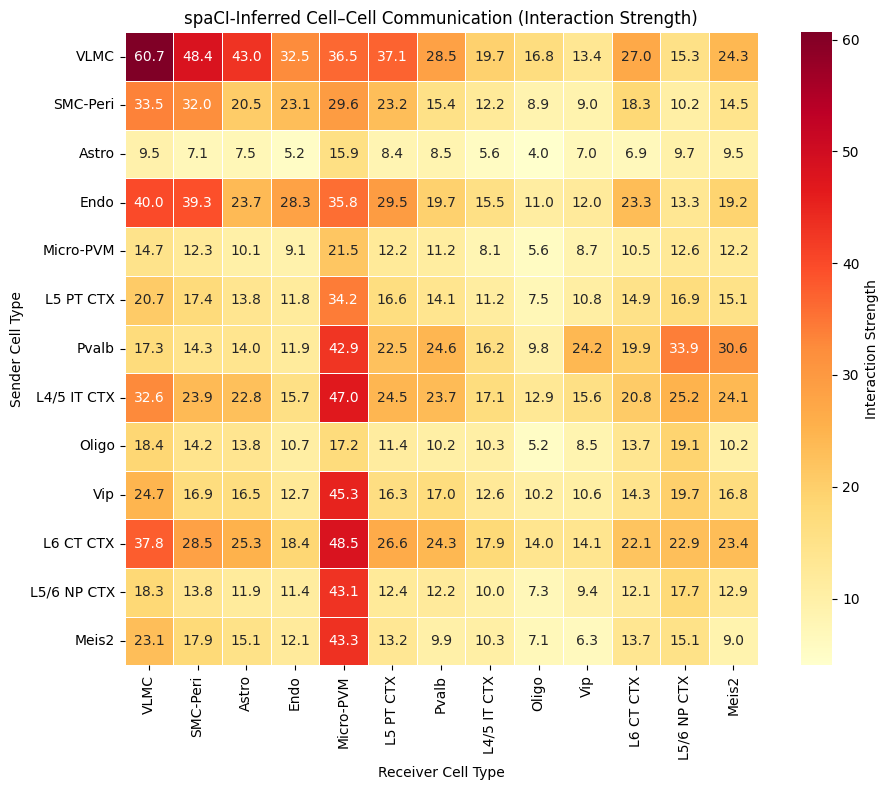

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(interaction_matrix,
            cmap="YlOrRd",
            annot=True,
            fmt=".1f",
            linewidths=0.5,
            square=True,
            cbar_kws={'label': 'Interaction Strength'})
plt.title("spaCI-Inferred Cell–Cell Communication (Interaction Strength)")
plt.xlabel("Receiver Cell Type")
plt.ylabel("Sender Cell Type")
plt.tight_layout()
plt.show()

### cell-type interaction strength inferred from predicted LR pairs

In [9]:
# Save spaCI final cell-type interaction matrix
spaci_mat = interaction_matrix.copy()
spaci_mat.to_csv("/home/akram/share/Result/spaCI_S1R1/spaCI_celltype_matrix.csv")
print("Saved: spaCI_celltype_matrix.csv")

Saved: spaCI_celltype_matrix.csv
